In [1]:
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from src.utils import get_path, find_closest_power_of_2
import numpy as np

# Fake config file to use get_path()
# EDITABLE
config = {
    'dataset': {
        'dir': './data',
        'name': 'MNIST0',
    }
}
n_data, n_pixels, n_timesteps, n_ancilla_qubits, n_backward_layers = 1000, 64, 40, 4, 9
_, n_qubits = find_closest_power_of_2(n_pixels, return_power=True)
diffusion_schedule = 'linear1'

In [2]:
dir = Path("data/MNIST0/results_optuna")
filename = "results.yaml"

with open(dir / filename, "r") as f:
    results = yaml.safe_load(f)

losses = []
Ls = []
for i in range(1, len(results)+1):
    Ls.append(results[i]["L"])
    losses.append(results[i]["loss"])

/tmp/ipykernel_2244735/1972990367.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, 'Optuna optimization of the number of layers L.\nThe numbers are L values.')

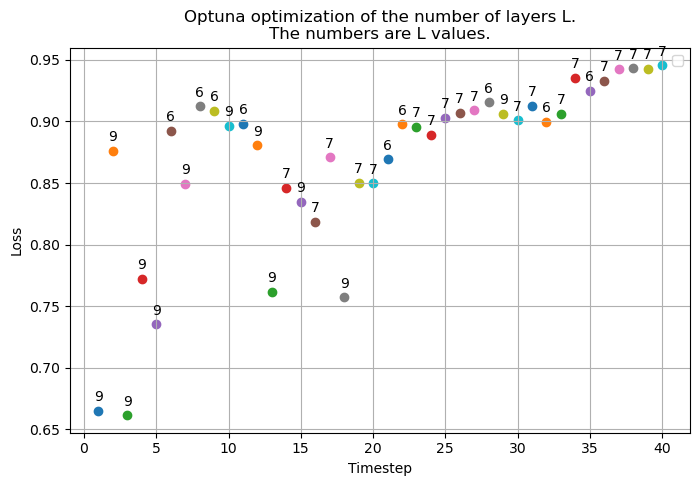

In [4]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

for i, (L, loss) in enumerate(zip(Ls, losses)):
    ax.scatter(i+1, loss)

    ax.annotate(
        f'{L}', 
        xy=(i + 1, loss),            # The point to annotate
        xytext=(0, 7),               # 7 points vertical offset
        textcoords="offset points",  # Interpret xytext as offset from xy
        ha='center',                 # Horizontal alignment
        # va='bottom',               # Vertical alignment
        # fontsize=10,
        # fontweight='bold',
        # color="#000000"
    )

dir, filename = get_path(config, type='wassdistforward', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers)
wassforward = np.load(dir / filename)
# ax.plot(wassforward, 'o--', label='Target', mfc='white', markersize=8, lw=2)


ax.grid(True)
# ax.set_ylim(0.6, 01.0)
ax.set_xlabel("Timestep")
ax.set_ylabel("Loss")
ax.legend()
ax.set_title("Optuna optimization of the number of layers L.\nThe numbers are L values.")

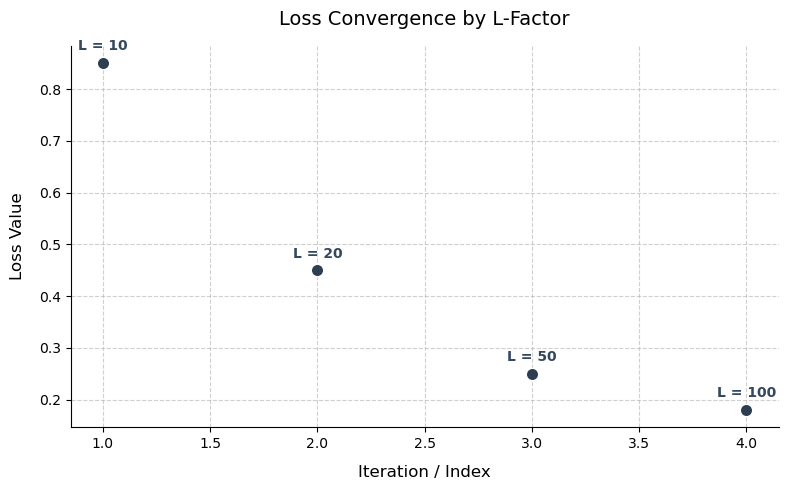

In [14]:
import matplotlib.pyplot as plt

# Sample data for demonstration
Ls = [10, 20, 50, 100]
losses = [0.85, 0.45, 0.25, 0.18]

# 1. Initialize the Object-Oriented API
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

# 2. Plot the scatter points
# Using 's' for size and 'c' with a map for better aesthetics
scatter = ax.scatter(range(1, len(losses) + 1), losses, 
                     color='#2c3e50', s=80, edgecolors='white', zorder=3)

# 3. Add annotations with offsets
for i, (L, loss) in enumerate(zip(Ls, losses)):
    ax.annotate(
        f'L = {L}', 
        xy=(i + 1, loss),            # The point to annotate
        xytext=(0, 7),               # 7 points vertical offset
        textcoords="offset points",  # Interpret xytext as offset from xy
        ha='center',                 # Horizontal alignment
        va='bottom',               # Vertical alignment
        fontsize=10,
        fontweight='bold',
        color='#34495e'
    )

# 4. Clean up the aesthetics (Removing "Chart Junk")
ax.set_xlabel("Iteration / Index", fontsize=12, labelpad=10)
ax.set_ylabel("Loss Value", fontsize=12, labelpad=10)
ax.set_title("Loss Convergence by L-Factor", fontsize=14, pad=15)

ax.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()